In [1]:
"""
AI vs DS vs ML vs DL

 AI : Mimics human behaviours , includes algorithms related to agents , bio informatics.
 DS : Subdivision of AI which uses Data to predict future behaviours
 ML : Subdivison of DS where feature engineering happens using proper algorithms (hand engineered) to train and test simple tasks
 DL : Subdision of ML where feature extractions are automatically  done using neural networks , not using human made algorithms

Machine learning Task Categories:
  1. Computer Vision ( Image Classification , Image segmentation..)
  2. Natural Language Processing
  3. Audio
  4. Multimodal
  5. Tabular

Example Project : Butterfly Classification
  Task : Computer Vision- Image Classification

1. Some SMART research questions needed
  S - Specific
  M - Measurable
  A - Achievable
  R - Relevant
  T - Time Bound

2. Organize the Research Questions and Distribute if team available
    R1,R2,R3,R4,R5 may be organized  as R3 >R1 > R5 > R4 > R2
    Distribute the RQs evenly among the teammates

3. Create Search Queries to filter the (3-5) Relevant Papers to each research question
4. Perform literature Review on that Research Question
    If RQ is already answered  -> pass the RQ
    If RQ is partially or no addressed -> scope

5. Design Experiment for the RQ
    Data
    Model
    Training
    Evaluation

6. Result Analysis ( Root Cause Analysis ) and Gap Identification
7. Propose a novel solution to solve the Gap


""";

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
import os

ROOT_DIR="E:\\BongoDev\\Machine_Learning\\"
DATA_DIR=os.path.join(ROOT_DIR,"data")

print(ROOT_DIR)
print(DATA_DIR)


E:\BongoDev\Machine_Learning\
E:\BongoDev\Machine_Learning\data


In [3]:
dataset_file=os.path.join(
    DATA_DIR,"housing_single_feature.csv"
)
print(dataset_file)

E:\BongoDev\Machine_Learning\data\housing_single_feature.csv


In [4]:
house_df=pd.read_csv(dataset_file)
house_df.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [5]:
"""
Task : Tabular - Regression
predict price from a given area

Estimated_price=per_sqft_price * area + registration_fee
"""

# STEP1 : Parameter Initialization
per_sft_price=np.random.randint(1,1000000)
registration_cost=np.random.randint(1,1000000)
print(per_sft_price)
print(registration_cost)

534828
441141


In [6]:
# Step 2: Define the ML Algorithm

def get_house_price(area,per_sft_price,registration_cost):
    estimated_price=per_sft_price * area + registration_cost
    return estimated_price

In [10]:
estimated_price=get_house_price(
    area=7420,
    per_sft_price=per_sft_price,
    registration_cost=registration_cost
)
print("Original_price",house_df.iloc[0]['price'])
print("estimated_price",estimated_price)

Original_price 13300000
estimated_price 3968864901


In [16]:
house_df['estimated_price']=[get_house_price(area,per_sft_price,registration_cost) for area in house_df['area'] ]
print(house_df.head())

   area     price  estimated_price
0  7420  13300000       3968864901
1  8960  12250000       4792500021
2  9960  12250000       5327328021
3  7500  12215000       4011651141
4  7420  11410000       3968864901


In [22]:
x=[]
y=[]
y_type=[]

for i in range(len(house_df)):
    x.append(house_df.iloc[i]['area'])
    y.append(house_df.iloc[i]['price'])
    y_type.append('y_true')

    x.append(house_df.iloc[i]['area'])
    y.append(house_df.iloc[i]['estimated_price'])
    y_type.append('y_pred')

np_x=np.array(x)
np_y=np.array(y)
np_y_type=np.array(y_type)

house_df=pd.DataFrame(
    {'area':np_x,
      'price':np_y,
     'type':np_y_type
     }
)
print(len(house_df))
print(house_df.head())




1090
   area       price    type
0  7420    13300000  y_true
1  7420  3968864901  y_pred
2  8960    12250000  y_true
3  8960  4792500021  y_pred
4  9960    12250000  y_true


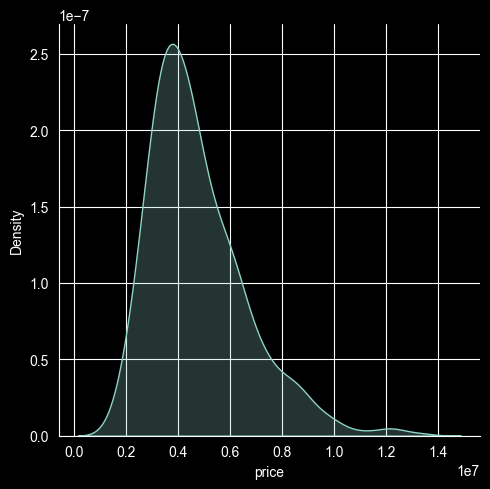

In [25]:
""" Probability Distribution function for actual house price given """

sns.displot(
    data=house_df.query('type=="y_true"'),
    x='price',
    kind='kde',
    fill=True,

)

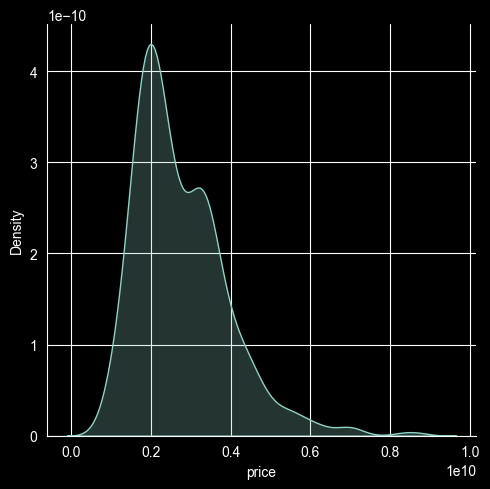

In [29]:
sns.displot(
    data=house_df.query('type=="y_pred"'),
    x='price',
    kind='kde',
    fill=True,
)

In [33]:
!pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -- ------------------------------------- 2.1/36.5 MB 10.8 MB/s eta 0:00:04
   ---- ----------------------------------- 3.9/36.5 MB 10.1 MB/s eta 0:00:04
   ----- ---------------------------------- 5.2/36.5 MB 8.6 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/36.5 MB 8.0 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/36.5 MB 7.1 MB/s eta 0:00:05
   --------- ------------------------------ 8.4/36.5 MB 6.8 MB/s eta 0:00:05
   ---------- ----------------------------- 9.2/36.5 MB 6.4 MB/s eta 0:00:05
   ----------- ---------------------------- 10.2/36.5 MB 6.2 MB/s eta 0:00:05
   ------------ --------------------------- 11.3/36.5 MB 6.1 MB/s eta 0:00:05
   ------------- -------------------------- 12.1/36.5 MB 5.9 MB/s eta 0:00:05
   -------------- ------------------------- 12.8/36.5 MB 5.7 MB/s eta 0:00:05
   -------------- ------------------------- 13.4/36.5 MB 5.5 MB/s eta 0:00:05


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [38]:
"""
KL ( Kullback-Leibler)DIVERGENCE : Measures the dissimilarity between two distributions
KLD =0 : same distribution
"""

from scipy.stats import entropy
def calculate_kl_divergence(df,epsilon=1e-10,max_divergence=1e6):
    y_pred=df[df['type']=='y_pred']['price'].values
    y_true=df[df['type']=='y_true']['price'].values

    y_pred_prob=y_pred/np.sum(y_pred)
    y_true_prob=y_true/np.sum(y_true)

    kl_div=entropy(y_true_prob,y_pred_prob)

    if np.isinf(kl_div):
        kl_div=max_divergence

    return kl_div
kl_divergence=calculate_kl_divergence(house_df)
print("KL DIVERGENCE",kl_divergence)

KL DIVERGENCE 0.06382359462353397


In [30]:
"""
Data Generating Process/ System : Actual Entity who generate the tru generate date

ML: tried to mimic a fake data generating process that matches the distribution of the actual data generating process

Find the distribution differences between y_true_PDF and y_pred_PDF

KL Divergence=D( y_true_PDF || y_pred_PDF)

OBJECTIVES of any ML
-------------------------
- Increase Maximum likelihood estimation
- Reduce Dissimilarity between distributions ( Predicted vs True)
- Reduce KL Divergence
- Minimize Some error/ loss / cost objective function

"""